In [5]:
import pandas as pd

# Load dataset
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display basic information
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFirst 5 Rows:")
print(df.head())

print("\nChurn Distribution:")
print(df['Churn'].value_counts())

print("\nStatistical Summary:")
print(df.describe())


# Check missing values
print(df.isnull().sum())

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check missing values again
print("\nMissing Values After Conversion:")
print(df.isnull().sum())

# Remove rows with missing values
df = df.dropna()

# Verify dataset shape
print("\nDataset Shape After Cleaning:")
print(df.shape)

Dataset Shape:
(7043, 21)

Column Names:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-n

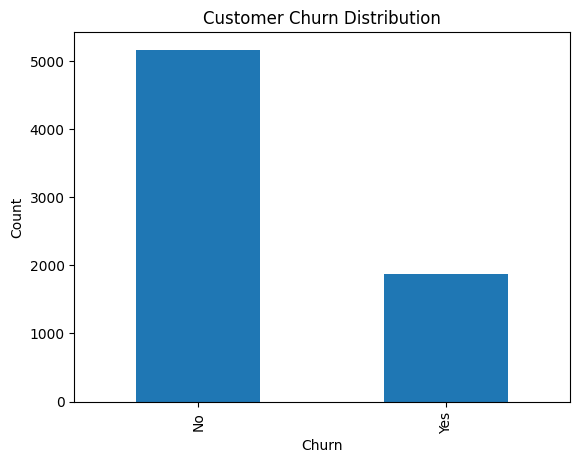

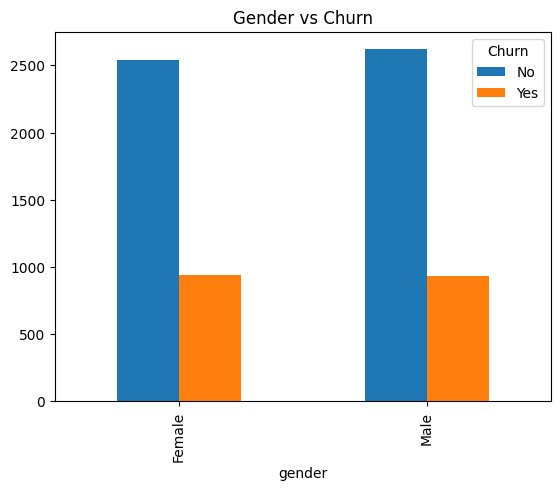

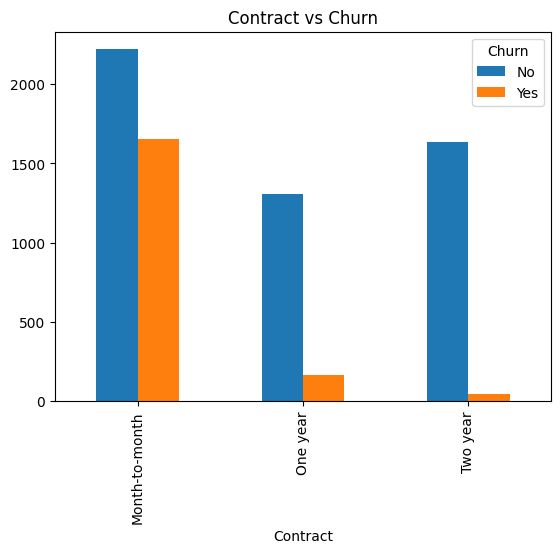

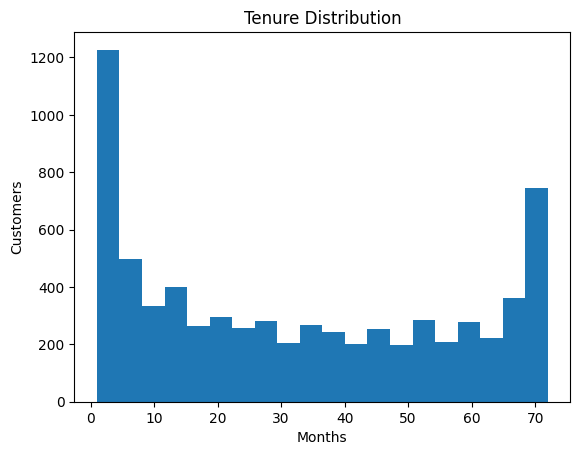

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Churn Distribution
df['Churn'].value_counts().plot(kind='bar')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

# Gender vs Churn
pd.crosstab(df['gender'], df['Churn']).plot(kind='bar')
plt.title('Gender vs Churn')
plt.show()

# Contract vs Churn
pd.crosstab(df['Contract'], df['Churn']).plot(kind='bar')
plt.title('Contract vs Churn')
plt.show()

# Tenure Distribution
plt.hist(df['tenure'], bins=20)
plt.title('Tenure Distribution')
plt.xlabel('Months')
plt.ylabel('Customers')
plt.show()

In [7]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Features and Target
X = df.drop('Churn', axis=1)
y = df['Churn']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7846481876332623
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.45      0.53       374

    accuracy                           0.78      1407
   macro avg       0.73      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



            Feature  Importance
19     TotalCharges    0.152603
18   MonthlyCharges    0.149936
5            tenure    0.136431
0        customerID    0.126720
15         Contract    0.085540
9    OnlineSecurity    0.044376
17    PaymentMethod    0.043136
12      TechSupport    0.036093
8   InternetService    0.023598
10     OnlineBackup    0.023139


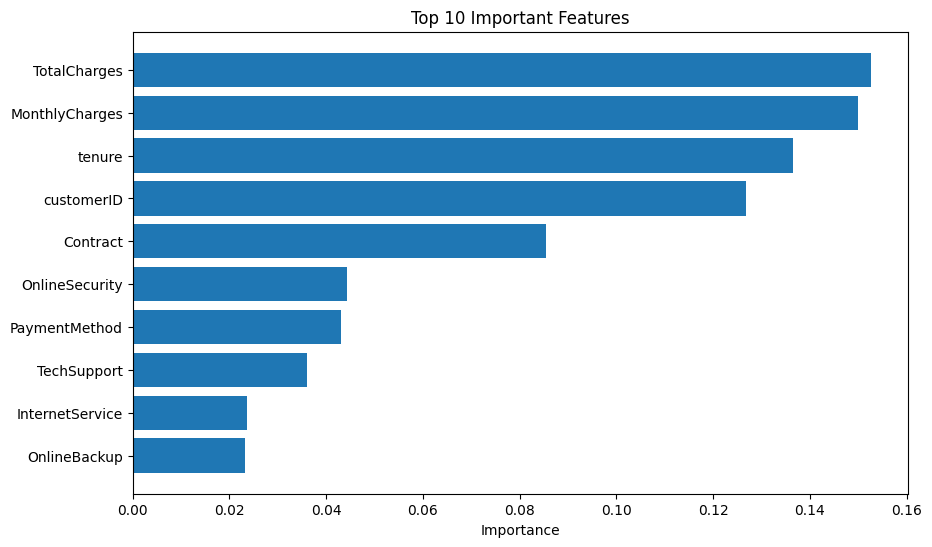

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

plt.figure(figsize=(10,6))
plt.barh(
    feature_importance['Feature'][:10],
    feature_importance['Importance'][:10]
)
plt.xlabel('Importance')
plt.title('Top 10 Important Features')
plt.gca().invert_yaxis()
plt.show()